In [95]:
import pandas as pd

In [96]:
iris_data = pd.read_csv('Iris.csv')

In [97]:
iris_data.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [98]:
iris_data.shape

(150, 6)

In [99]:
iris_data.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [100]:
iris_data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [101]:
iris_data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [102]:
iris_data.drop('Id', axis=1, inplace=True)

In [103]:
iris_data['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Iris Species')

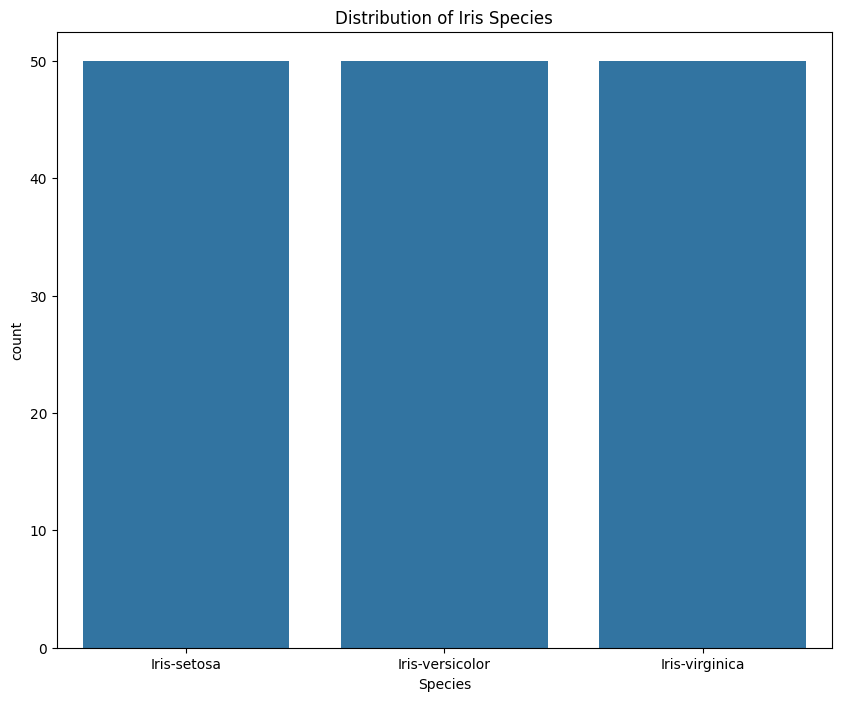

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.countplot(x='Species',data=iris_data)
plt.title('Distribution of Iris Species')

In [105]:
iris_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


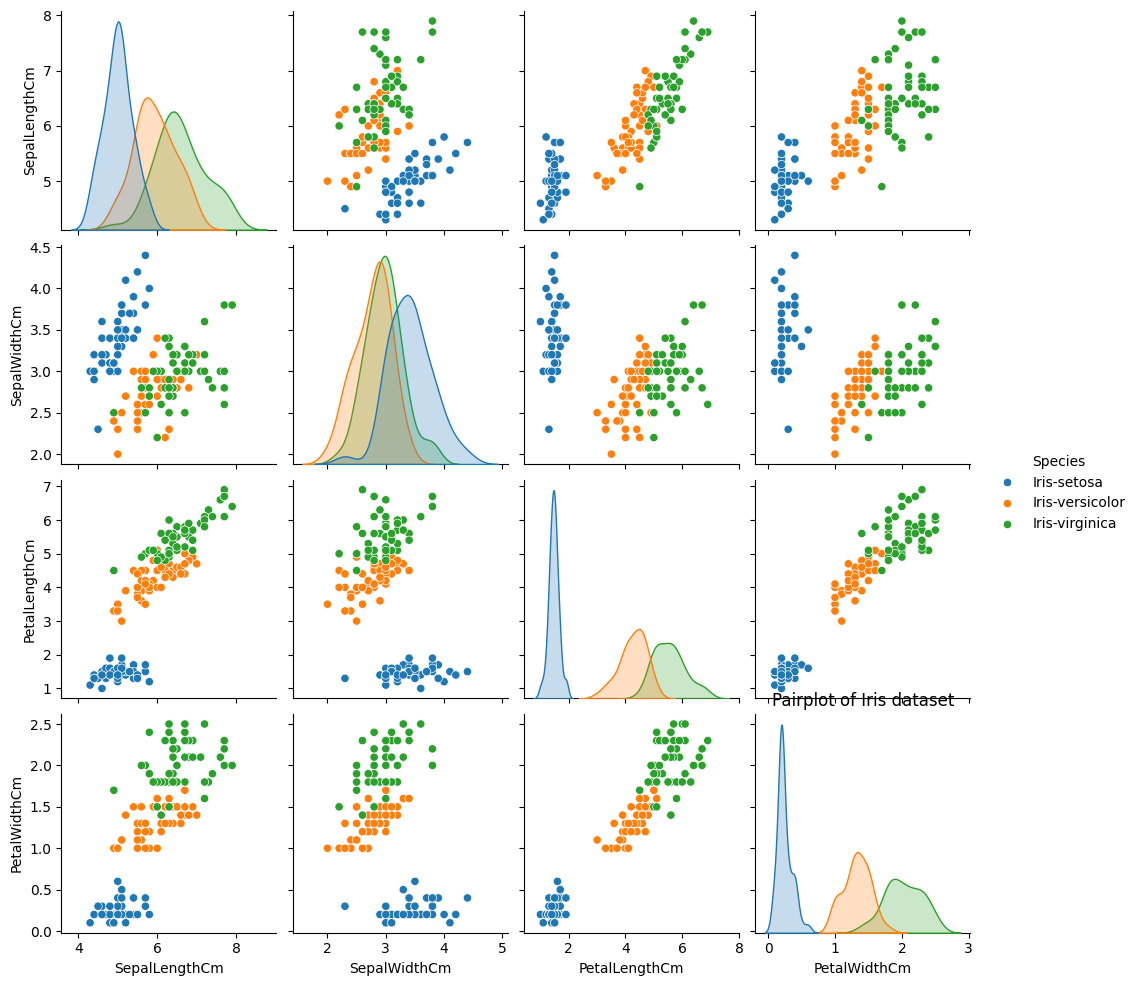

In [121]:
sns.pairplot(iris_data, hue='Species')
plt.title("Pairplot of Iris dataset")
plt.show()

<Axes: >

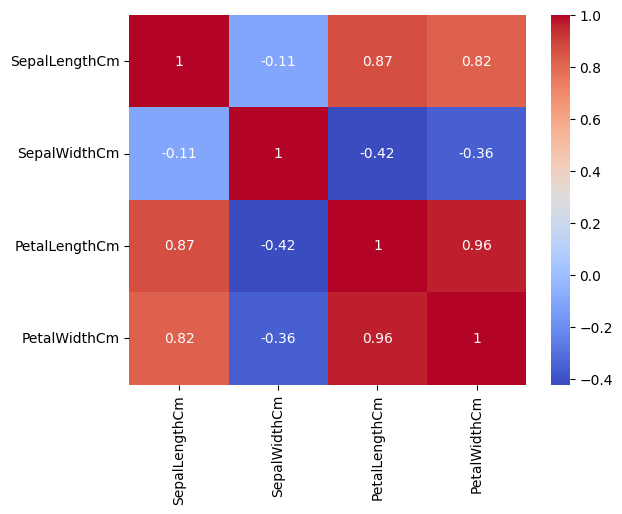

In [107]:
numerical_features = iris_data.select_dtypes(exclude='object')

numerical_corr = numerical_features.corr()
sns.heatmap(numerical_corr, cmap='coolwarm', annot=True)

Petal Lenght and Petal width are the most strongly correlated features

Text(0.5, 1.0, 'Box plot of SepalLengthCm grouped by species')

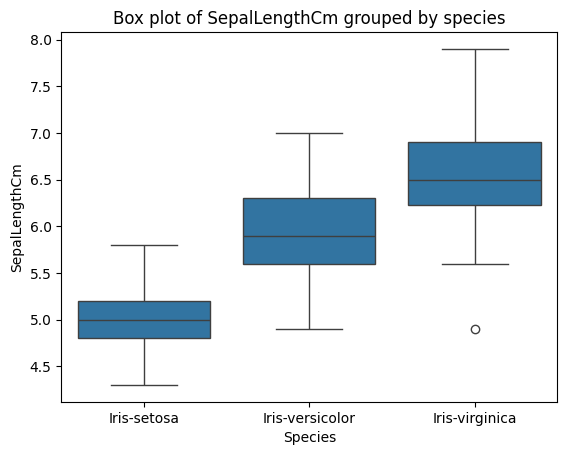

In [108]:
sns.boxplot(x='Species', y = 'SepalLengthCm', data=iris_data,)
plt.title("Box plot of SepalLengthCm grouped by species")


Text(0.5, 1.0, 'Box plot of SepalWidthCm grouped by species')

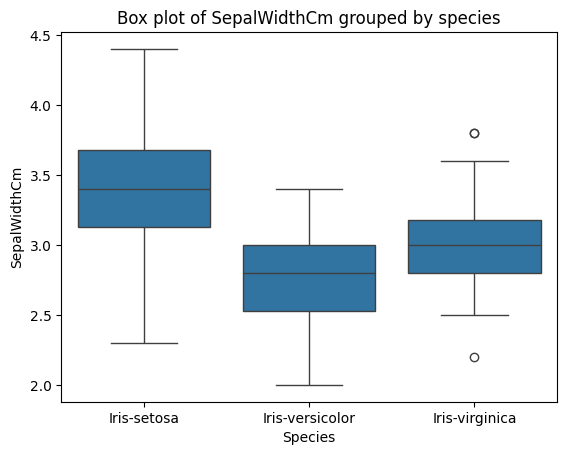

In [109]:
sns.boxplot(x='Species', y = 'SepalWidthCm', data=iris_data)
plt.title("Box plot of SepalWidthCm grouped by species")

Text(0.5, 1.0, 'Box plot of PetalLengthCm grouped by species')

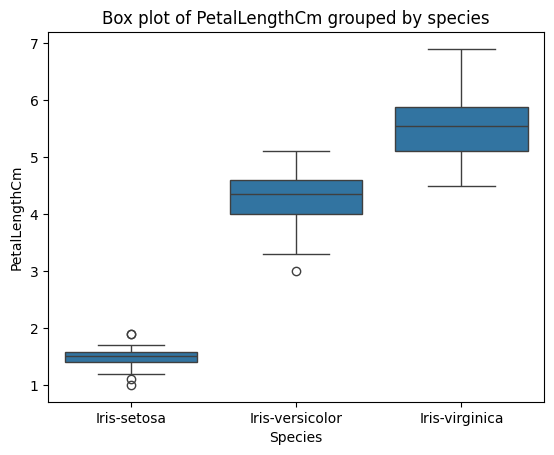

In [110]:
sns.boxplot(x='Species', y = 'PetalLengthCm', data=iris_data)
plt.title("Box plot of PetalLengthCm grouped by species")

Text(0.5, 1.0, 'Box plot of PetalWidthCm grouped by species')

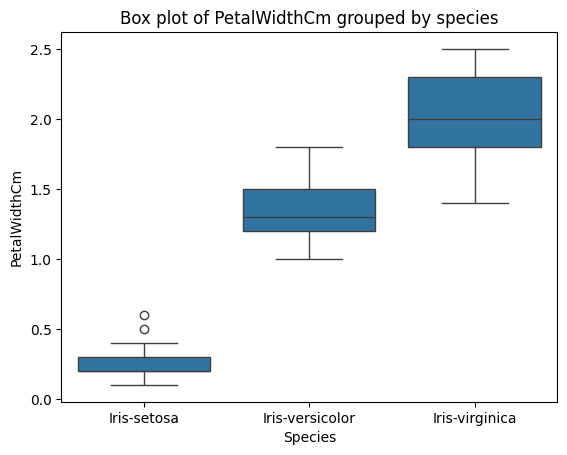

In [111]:
sns.boxplot(x='Species', y = 'PetalWidthCm', data=iris_data)
plt.title("Box plot of PetalWidthCm grouped by species")

Petal Lenght best separates the features since there are very few over lapping features in the petal length

In [112]:
from sklearn.model_selection import train_test_split

ML_data = iris_data.copy()

X = ML_data.drop(columns='Species')
y = ML_data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [113]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
k_values = [3, 5, 7, 9, 11]
k_accuracy = []

for k in k_values:
    Knn = KNeighborsClassifier(k)
    Knn.fit(X_train, y_train)
    y_pred = Knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"K Value = {k} and Accuracy = {accuracy:.4}")
    k_accuracy.append(accuracy)
    

K Value = 3 and Accuracy = 1.0
K Value = 5 and Accuracy = 1.0
K Value = 7 and Accuracy = 0.9667
K Value = 9 and Accuracy = 1.0
K Value = 11 and Accuracy = 1.0


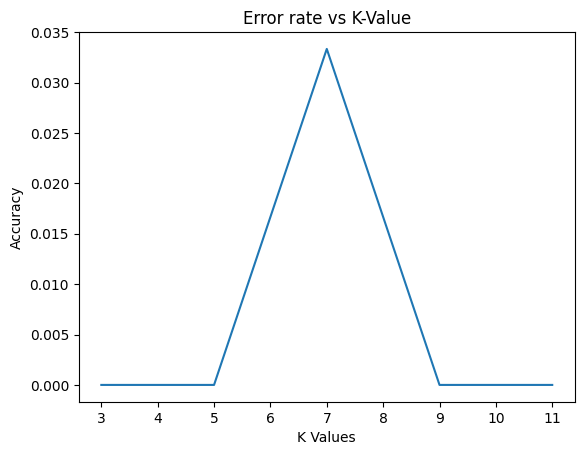

In [114]:
k_accuracy

error_rate = []

for acc in k_accuracy:
    error = 1 - acc
    error_rate.append(error)

import matplotlib.pyplot as plt
plt.plot(k_values,error_rate)
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("Error rate vs K-Value")
plt.show()

<Axes: >

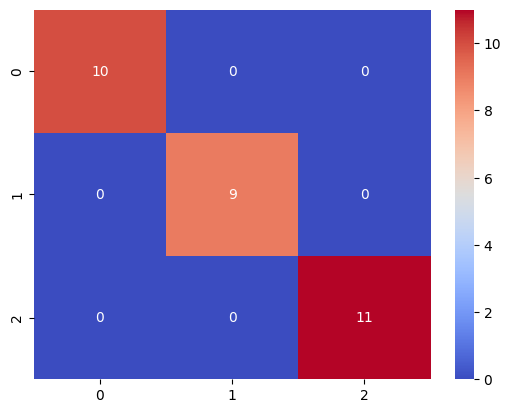

In [118]:
from sklearn.metrics import confusion_matrix

Knn = KNeighborsClassifier(3)
Knn.fit(X_train, y_train)
y_pred = Knn.predict(X_test)
cm= confusion_matrix(y_test, y_pred)
cm

sns.heatmap(cm, annot=True, cmap='coolwarm')

Based on the confusion matrix Iris-versicolor is the hardest to classify

In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

